<h1 align='center'> Narrative as a trajectory through semantic space... </h1>


- model narrative as context-dependent vectors in semantic space
- estimate influence of narrative location on semantic similarity 
- discover scene structure 
- within-dim similarity > btween-dim similarity 
- view choices as changes in task trajectory


https://naturalistic-data.org/content/Natural_Language_Processing.html

- can compare varying amounts of context, etc


TODO: 
- plot with the text
- 

In [1]:
from utils import *
import sys
sys.path.append('../')
from utils_nlp import * 

from typing import Dict

import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics.cluster import adjusted_mutual_info_score
from sklearn.model_selection import StratifiedShuffleSplit, LeaveOneOut, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression

# some utilities
def plot_scatter(fig, embedding, colors, text, row, col):
    """
    Plots a 2D or 3D scatter plot on the given subplot in the figure based on the shape of the embedding.
    
    Parameters:
    fig (plotly.graph_objects.Figure): The figure to plot on.
    embedding (np.ndarray): The input embeddings to plot.
    colors (list or np.ndarray): The colors for each point.
    text (list of str): Text labels for each point, shown when hovering.
    row (int): The row index of the subplot.
    col (int): The column index of the subplot.
    """
    if embedding.shape[1] == 2:
        scatter = go.Scatter(
            x=embedding[:, 0], y=embedding[:, 1],
            mode='markers',
            marker=dict(size=8, color=colors, opacity=0.8),
            text=text,  # Set the hover text
            hoverinfo='text',  # Specify that only text is displayed on hover
            name=''
        )
    elif embedding.shape[1] == 3:
        scatter = go.Scatter3d(
            x=embedding[:, 0], y=embedding[:, 1], z=embedding[:, 2],
            mode='markers',
            marker=dict(size=8, color=colors, opacity=0.8),
            text=text,  # Set the hover text
            hoverinfo='text',  # Specify that only text is displayed on hover
            name=''
        )
    else:
        raise ValueError("Embedding must have 2 or 3 dimensions.")

    fig.add_trace(scatter, row=row, col=col)

def replace_pronouns(df: pd.DataFrame, character_genders: Dict[str, str]) -> pd.DataFrame:
    """
    Replace bracketed placeholders in columns ['text','opt1_text','opt2_text'] using only
    the provided character_genders mapping:
      {'First': 'man'/'woman', 'Second': ..., 'Assistant': ..., 'Newcomb': ..., 'Hayworth': ..., 'Neutral': ...}

    Behavior
    --------
    • Pronouns for each role (subject/object/possessives/reflexive) and contractions ('is','would','will')
    • Titles/specials: [Mr./Mrs. X character], [X character sir/ma'am], [X character guy/girl], [X character man/woman]
    • Names:
        - First & Second:     man→Chris  | woman→Jessica
        - Assistant & Neutral: man→Anthony | woman→Kayce
        - Newcomb & Hayworth: fixed "Newcomb" / "Hayworth"
      Replaces: [X character name], [X character first name]
    • Newcomb possessive: [Newcomb character possessive] → "Newcomb's"
      (others: → his/her according to gender)
    • Newcomb spouse: opposite Newcomb gender; name = "James" (man) or "Mary" (woman)
      Replaces: [Newcomb character spouse's name], [Newcomb character spouse's pronoun]
    • Any unrecognized tokens are left as-is.

    Notes
    -----
    • Female title is "Mrs." (per your preference).
    """

    required_cols = {'text','opt1_text','opt2_text'}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # ---------- helpers ----------
    def forms_for_gender(g: str):
        g = (g or '').strip().lower()
        if g == 'woman':
            return dict(
                subj='she', obj='her', poss_det='her', poss_pron='hers', refl='herself',
                is_contr="she's", would_contr="she'd", will_contr="she'll",
                guy_girl='girl', sir_maam="ma'am", man_woman='woman', mr_mrs='Mrs.'
            )
        # default to 'man'
        return dict(
            subj='he', obj='him', poss_det='his', poss_pron='his', refl='himself',
            is_contr="he's", would_contr="he'd", will_contr="he'll",
            guy_girl='guy', sir_maam='sir', man_woman='man', mr_mrs='Mr.'
        )

    def name_for_role(role: str, gender: str) -> str:
        gender = (gender or 'man').lower()
        if role in ('First', 'Second'):
            return 'Chris' if gender == 'man' else 'Jessica'
        if role in ('Assistant', 'Neutral'):
            return 'Anthony' if gender == 'man' else 'Kayce'
        if role == 'Newcomb':
            return 'Newcomb'
        if role == 'Hayworth':
            return 'Hayworth'
        # fallback
        return role

    roles = ['First','Second','Assistant','Newcomb','Hayworth','Neutral']
    role_forms = {r: forms_for_gender(character_genders.get(r, 'man')) for r in roles}
    role_names = {r: name_for_role(r, character_genders.get(r, 'man')) for r in roles}

    # Newcomb spouse (opposite gender)
    newcomb_gender = (character_genders.get('Newcomb','man') or 'man').lower()
    spouse_gender = 'woman' if newcomb_gender == 'man' else 'man'
    spouse_forms = forms_for_gender(spouse_gender)
    spouse_name = 'Mary' if spouse_gender == 'woman' else 'James'

    # ---------- build replacement rules ----------
    replacements = []
    def pat(token: str) -> re.Pattern:
        return re.compile(re.escape(token))

    for role in roles:
        f = role_forms[role]
        nm = role_names[role]
        # Core pronouns + contractions
        mapping = {
            f'[{role} character pronoun]': f['subj'],
            f'[{role} character objective]': f['obj'],
            f'[{role} character reflexive]': f['refl'],
            f'[{role} character possessive pronoun]': f['poss_pron'],
            f'[{role} character possessive determiner]': f['poss_det'],
            f'[{role} character \'is\' contraction]': f['is_contr'],
            f'[{role} character \'would\' contraction]': f['would_contr'],
            f'[{role} character \'will\' contraction]': f['will_contr'],
            f'[Mr./Mrs. {role} character]': f['mr_mrs'],
            f'[{role} character sir/ma\'am]': f['sir_maam'],
            f'[{role} character guy/girl]': f['guy_girl'],
            f'[{role} character man/woman]': f['man_woman'],
            f'[{role} character name]': nm,
            f'[{role} character first name]': nm,
        }
        # Generic "[X character possessive]" → pronoun poss. determiner, except Newcomb handled later
        if role != 'Newcomb':
            mapping[f'[{role} character possessive]'] = f['poss_det']

        for k, v in mapping.items():
            replacements.append((pat(k), v))

    # Newcomb-specific overrides & spouse
    replacements.append((pat('[Newcomb character possessive]'), "Newcomb's"))
    replacements.append((pat("[Newcomb character spouse's name]"), spouse_name))
    replacements.append((pat("[Newcomb character spouse's pronoun]"), spouse_forms['subj']))

    # Also ensure explicit tokens common in your script map correctly
    replacements.append((pat("[Hayworth character sir/ma'am]"), role_forms['Hayworth']['sir_maam']))
    replacements.append((pat('[Second character guy/girl]'), role_forms['Second']['guy_girl']))
    replacements.append((pat('[Newcomb character man/woman]'), role_forms['Newcomb']['man_woman']))

    # Cleanup: collapse double spaces that might arise after substitutions
    space_fix = re.compile(r' {2,}')

    def _apply(text):
        if not isinstance(text, str):
            return text
        out = text
        for rx, repl in replacements:
            out = rx.sub(repl, out)
        out = space_fix.sub(' ', out)
        return out

    out = df.copy()
    for col in ['text','opt1_text','opt2_text']:
        out[col] = out[col].map(_apply)

    return out


# snt info
snt_df = snt_df[np.isfinite(snt_df['trial_num'])]
snt_df = snt_df.sort_values(by='trial_num').reset_index(drop=True)
snt_df = snt_df[snt_df['slide_type'] != 'Game over'].reset_index(drop=True)
snt_df['word_count'] = snt_df['text'].apply(lambda x: len(x.split())) # word count 
character_genders = {'First': 'man', 'Second': 'woman', 'Assistant': 'man',
                    'Newcomb': 'woman', 'Hayworth': 'man', 'Neutral': 'woman'}
snt_df = replace_pronouns(snt_df, character_genders)

# isolate decisions
decision_snt_df = snt_df[snt_df['slide_type'] == 'Decision'].reset_index(drop=True)
choice_text = decision_snt_df[['opt1_text', 'opt2_text']].values
model_names = ['mpnet', 'google']

## Embed text & get other text features

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

In [4]:
#---------------------------------------- embeddings

n_prev_slides = 2
fname = f'../data/narratives/task-embeddings/generic_narrative_embeddings_{n_prev_slides}slide-context.pkl'
overwrite = False
if (os.path.exists(fname)) and not overwrite:
    semantic_dict = load_pickle(fname)

else: 
    models = ['mpnet', 'google']
    semantic_dict = {model: [] for model in models }
    
    # Replace placeholders in the text & get embeddings
    gender_versions = [['woman', 'man', 'man', 'man', 'woman', 'woman'], 
                       ['man', 'woman', 'woman', 'woman', 'man', 'man']]
    for genders in gender_versions:
        character_genders = {'First': genders[0], 'Second': genders[1], 'Assistant': genders[2],
                            'Newcomb': genders[3], 'Hayworth': genders[4], 'Neutral': genders[5]}
        slides = list(replace_pronouns(snt_df, character_genders)['text'].values)
        slides_in_context = text_in_context(slides, n_prev_slides)
        for model in models:
            semantic_dict[model].append(get_sentence_embeddings(slides_in_context, model=model))

    # Average the embeddings across the different versions
    for model in models:
        semantic_dict[model] = np.mean(np.array(semantic_dict[model]), axis=0)
    pickle_file(semantic_dict, fname)

#---------------------------------------- sentiment analysis

from transformers import pipeline
sentiment_model = pipeline("sentiment-analysis", 
                           model="cardiffnlp/twitter-roberta-base-sentiment", 
                           return_all_scores=True) 

def calculate_compound_score(sentiment):
    
    positive = sentiment[[k for k in sentiment.keys() if 'positivity' in k][0]]
    negative = sentiment[[k for k in sentiment.keys() if 'negativity' in k][0]]
    neutral  = sentiment[[k for k in sentiment.keys() if 'neutrality' in k][0]]

    # Normalize scores --> probabilities
    total = positive + negative + neutral
    positive_norm = positive / total
    negative_norm = negative / total
    neutral_norm  = neutral / total
    
    # Simple compound score calculation
    # - scale by neutral to reduce the compound score when the sentiment is mostly neutral
    compound_score = (positive_norm - negative_norm) * (1 - neutral_norm)
    return np.round(compound_score, 3)

def run_sentiment_analysis(text):
    sentiment = sentiment_model(text)[0]
    sentiment = {sent['label']: np.round(sent['score'], 3) for sent in sentiment}
    label_mapping = {'LABEL_0': 'negativity', 'LABEL_1': 'neutrality', 'LABEL_2': 'positivity'} 
    sentiment = {label_mapping[k]: v for k, v in sentiment.items() if k in label_mapping}
    sentiment['compound'] = calculate_compound_score(sentiment)
    return sentiment

sentiments = [run_sentiment_analysis(text) for text in snt_df['text']]
sentiment_df = pd.DataFrame(sentiments)
snt_df[sentiment_df.columns] = sentiment_df

An error occurred: name 'genai' is not defined
An error occurred: name 'genai' is not defined


Device set to use mps:0


<h1 align='center'> Visualize some features over time </h1>

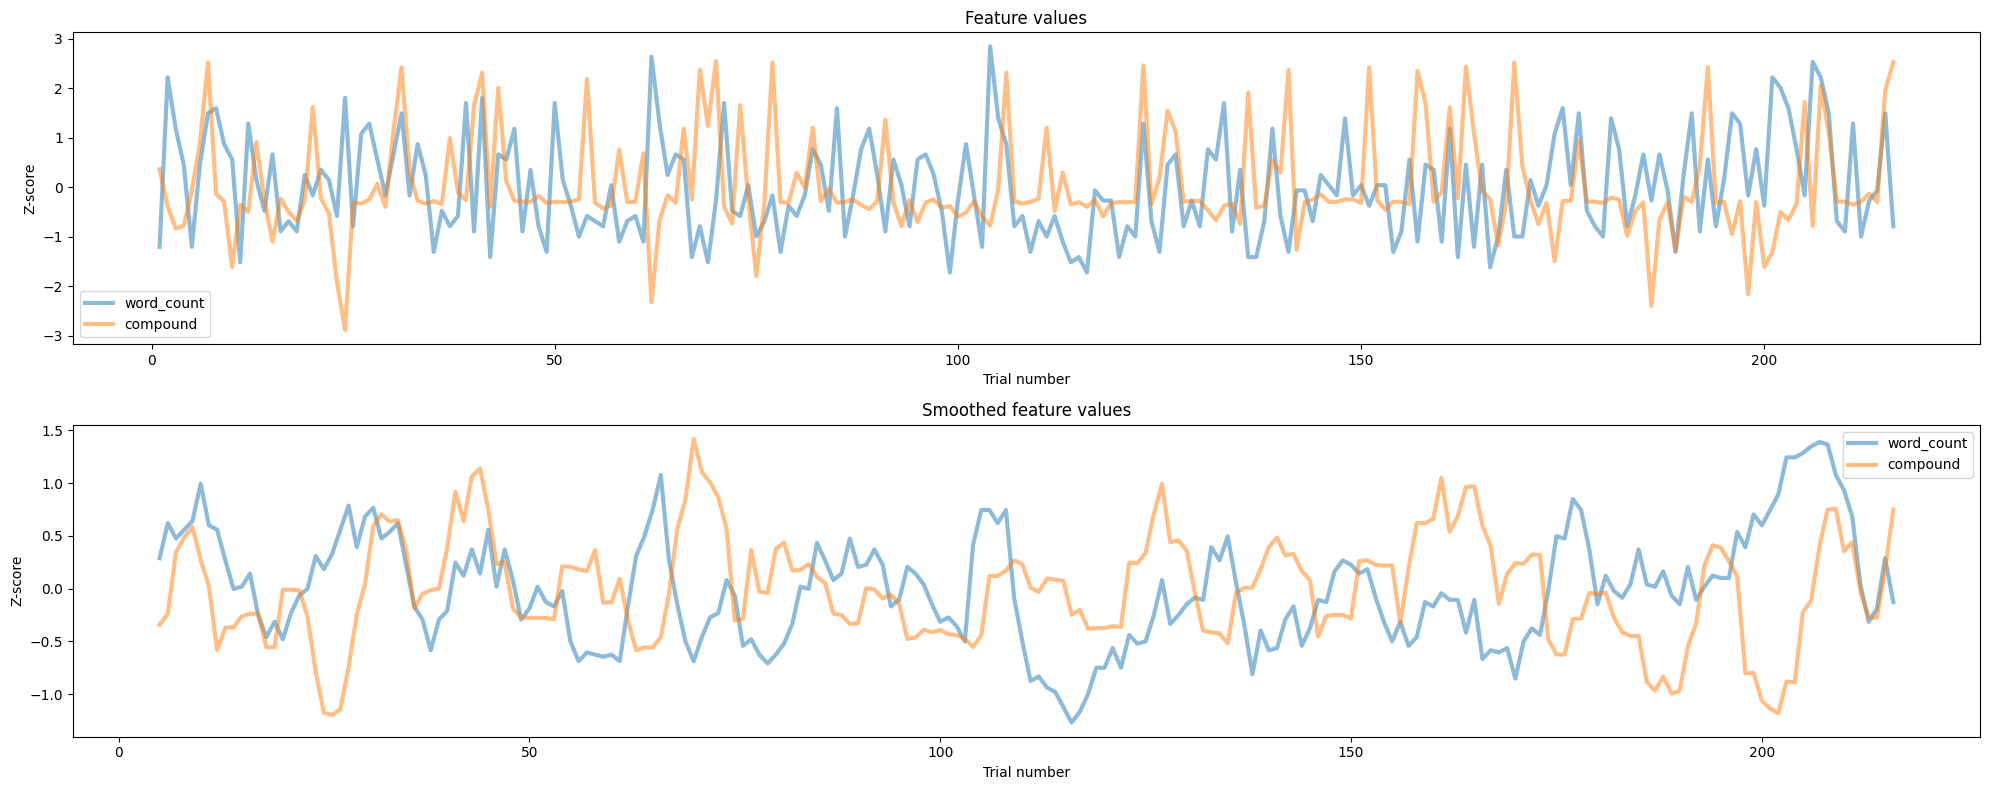

In [5]:
features = ['word_count', 'compound']

# z-score + smoothing
for f in features:
    snt_df[f'{f}_z'] = scipy.stats.zscore(snt_df[f])
    snt_df[f'{f}_smooth'] = snt_df[f'{f}_z'].rolling(window=5).mean()
    
# compute the average feature values
snt_df['average_feature'] = snt_df[features].mean(axis=1)
snt_df['average_feature_z'] = scipy.stats.zscore(snt_df['average_feature'])
snt_df['average_feature_smooth'] = snt_df['average_feature_z'].rolling(window=5).mean()

# plot
fig, axs = plt.subplots(2, 1, figsize=(20, 8))
for f in features:
    ax = axs[0]
    sns.lineplot(x=snt_df['trial_num'], y=snt_df[f'{f}_z'], 
                 alpha=0.5, linewidth=3, label=f, ax=ax)
    ax.set_title('Feature values')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Z-score')
    ax = axs[1]
    sns.lineplot(x=snt_df['trial_num'], y=snt_df[f'{f}_smooth'], 
                 alpha=0.5, linewidth=3, label=f, ax=ax)
    ax.set_title('Smoothed feature values')
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Z-score')

plt.tight_layout()

<h1 align='center'> Structure of narrative is captured in semantic patterns </h1>


could do this in a sliding window way to really see the trajectory...

In [ ]:
# slides = list(replace_pronouns(snt_df, character_genders)['text'].values)
# slides_in_context = text_in_context(slides, 3)
# print('Slides in context:', len(slides_in_context), len(slides_in_context))
# embds = get_sentencetransformer_embeddings(slides_in_context, model=model)
# print('Embeddings:', embds.shape)

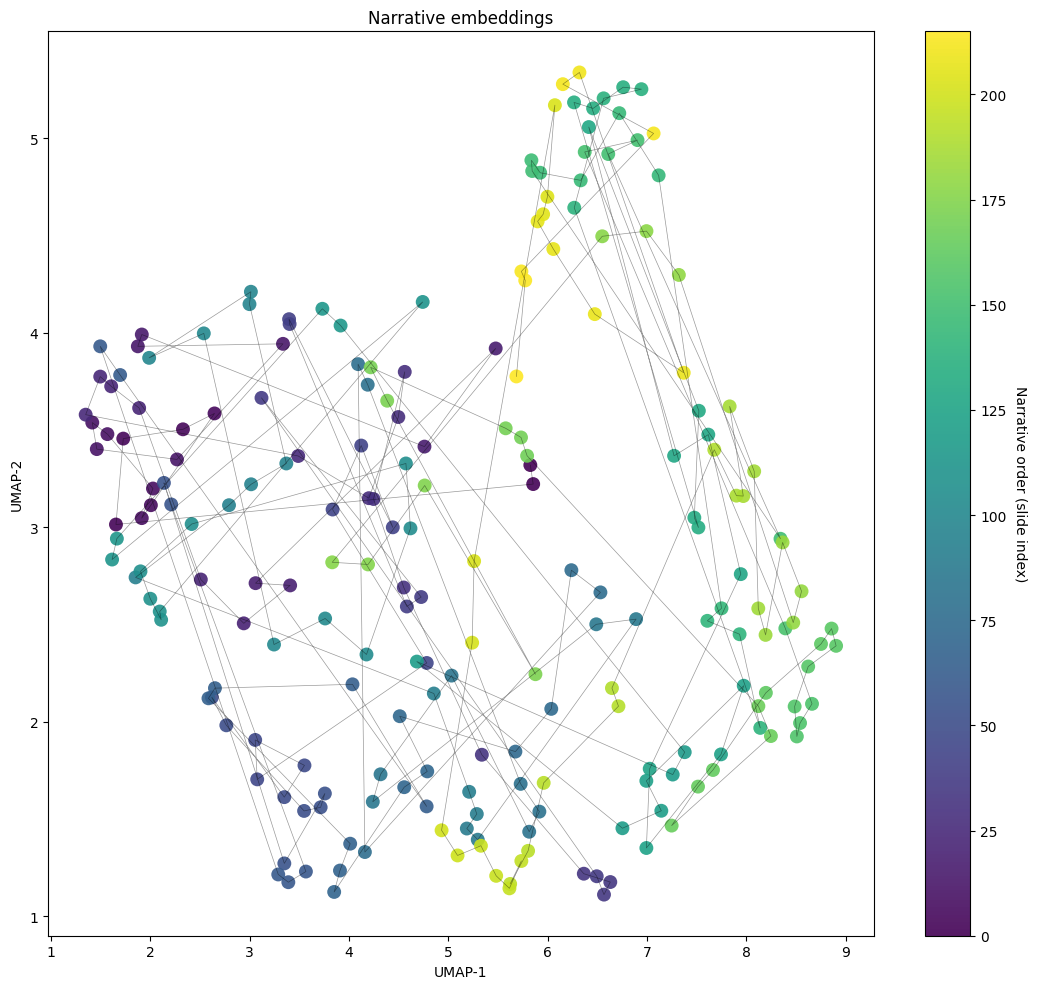

In [12]:
embds = semantic_dict['mpnet']
import umap

# 1) Project to 2D with UMAP
reducer = umap.UMAP(
    n_components=2,
    random_state=42,   # for reproducibility
    n_neighbors=15,    # tweak if you want more local vs global structure
    min_dist=0.1
)
embds_2d = reducer.fit_transform(embds)  # shape (n_slides, 2)

# 2) Color code by narrative order (earlier → later)
n_slides = embds.shape[0]
slide_idx = np.arange(n_slides)  # 0, 1, 2, ..., n_slides-1

plt.figure(figsize=(11, 10))

sc = plt.scatter(
    embds_2d[:, 0],
    embds_2d[:, 1],
    c=slide_idx,
    cmap="viridis",    # or "plasma", "cividis", etc.
    s=100,
    alpha=0.9,
    edgecolor="none",
)

# Optional: connect points in order to emphasize the trajectory
plt.plot(
    embds_2d[:, 0],
    embds_2d[:, 1],
    linewidth=0.5,
    alpha=0.4,
    color="k"
)

cbar = plt.colorbar(sc)
cbar.set_label("Narrative order (slide index)", rotation=270, labelpad=15)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("Narrative embeddings")
plt.tight_layout()
plt.show()


<h1 align='center'> Clustering the semantic vectors captures the scene structure </h1>

### Cosine similarity between slides in context

In [ ]:
for scene_type in ['low-level', 'high-level']:
    unique_scenes = unique_in_order(snt_df[f'scene_{scene_type}'].values)
    scene_dict = {scene: i for i, scene in enumerate(unique_scenes)}
    snt_df[f'scene_num_{scene_type}'] = snt_df[f'scene_{scene_type}'].apply(lambda x: scene_dict[x])
scene_lowlevel_ix  = np.where(np.diff(snt_df['scene_num_low-level'].values) != 0)[0] + 1
scene_highlevel_ix = np.where(np.diff(snt_df['scene_num_high-level'].values) != 0)[0] + 1

In [ ]:
fig, axs = plt.subplots(len(model_names), 1, figsize=(15, 3*len(model_names)))
for i, model_name in enumerate(model_names):

    # each trial will have a similarity to the previous and to the next trial
    cosine_matrix   = 1-pairwise_distances(semantic_dict[model_name], metric='cosine')
    cosine_sim_prev = np.array([np.nan] + [cosine_matrix[i, i-1] for i in range(1, cosine_matrix.shape[0])])
    cosine_sim_next = np.array([cosine_matrix[i, i+1] for i in range(cosine_matrix.shape[0]-1)] + [np.nan])
    assert len(cosine_sim_prev) == len(cosine_sim_next) == len(cosine_matrix)

    # applying some smoothing
    window_size = 10
    cosine_sim_prev_sm = np.convolve(cosine_sim_prev, np.ones(window_size)/window_size, mode='valid')

    ax = axs[i]
    sns.lineplot(x=np.arange(len(cosine_sim_prev)), y=cosine_sim_prev, label='cosine', ax=ax)
    sns.lineplot(x=np.arange(len(cosine_sim_prev_sm)), y=cosine_sim_prev_sm, label='smoothed', ax=ax)
    for i in scene_lowlevel_ix:
        ax.axvline(x=i, color='blue', linestyle='--', alpha=0.5)
    ax.set_title(f'{model_name} similarity to previous slide')
    ax.set_ylabel('Cosine similarity\nto previous')
    ax.set_xlabel('Slide number')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()

### DBSCAN clustering in low-dimensional projection
- Project semantic vectors to lower dimensions (e.g., 5-10)
- Use grid-search to find the best DBSCAN parameters that maximize AMI between clusters & scenes
- Max AMI: non-linear projections > PCA projections
    - LLE captures the local, temporal structure of the scenes better...?
    - What could else be driving this? 

In [ ]:
def grid_search_dbscan(vectors, eps_values, min_samples_values):
    """
    Perform a grid search to find the best parameters for DBSCAN based on AMI.

    Parameters:
    vectors (np.ndarray): The feature vectors to cluster.
    scenes (pd.Series): The true labels (as scenes) for computing AMI.
    eps_values (list): The list of epsilon values to try.
    min_samples_values (list): The list of min_samples values to try.

    Returns:
    tuple: Best eps, best min_samples, and the highest AMI score obtained.
    """

    best_ami = 0
    best_params = (None, None)

    # Iterate over all combinations of eps and min_samples
    for eps in eps_values:
        for min_samples in min_samples_values:

            # Perform DBSCAN
            clusters = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(vectors)
            
            # Calculate AMI, ensuring there's more than one cluster and not all points are noise
            if len(np.unique(clusters)) > 1 and not np.all(clusters == -1):
                ami = adjusted_mutual_info_score(scene_ix, clusters)

                # Update best parameters if current AMI is better
                if ami > best_ami:
                    best_ami = ami
                    best_params = (eps, min_samples)

    # return the best parameters
    return best_params[0], best_params[1], best_ami

fig = make_subplots(
    rows=1, cols=3, 
    specs=[[{'type': 'scatter3d'} for _ in range(3)]],
    subplot_titles=list(semantic_vectors.keys())
)

# map the scenes to integers
scenes = snt_df['scene_low-level'].values
unique_scenes = unique_in_order(scenes)
scene_dict = {scene: i for i, scene in enumerate(unique_scenes)}
scene_ix = np.array([scene_dict[scene] for scene in scenes])

reduce_f = calc_lle_embedding
# reduce_f = calc_pca_embedding

# run grid search for different embedding models
for i, (model_name, vectors) in enumerate(semantic_dict.items()):

    #---------------------------------------------------------------
    # reduce + cluster 
    # w. grid-search optimization to find the best parameters for DBSCAN
    #---------------------------------------------------------------

    # reduce the dimensionality to make clustering easier
    vectors_reduced = reduce_f(semantic_dict[model_name], n_components=10)['embedding']

    # run grid search to find best params for neighborhoods
    best_eps, best_min_samples, best_ami = grid_search_dbscan(vectors_reduced, np.linspace(0.01, 0.1, 100), np.arange(1, 10)) # grid search
    clusters = DBSCAN(eps=best_eps, min_samples=best_min_samples).fit_predict(vectors_reduced) # use best params to cluster
    unique, counts = np.unique(clusters, return_counts=True)
    noise_points = counts[0]
    print(f"{model_name} grid search best: eps = {best_eps:.3f}, min_samples = {best_min_samples}, AMI = {best_ami:.3f}; n scenes = {np.sum(unique!=-1)}, n noise points = {noise_points}")

    vectors_reduced = reduce_f(semantic_dict[model_name], n_components=3)['embedding']
    plot_scatter(fig, vectors_reduced, clusters, None, row=1, col=i+1)
    
fig.update_layout(title_text='Embeddings', height=500, width=1200)
fig.show()

## Narrative similarity

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4.25))

for i, model_name in enumerate(model_names):
    trial_vectors = semantic_dict[model_name]
    trial_distances = pairwise_distances(trial_vectors, metric='cosine')
    
    ax = axs[i]
    sns.heatmap(trial_distances, cmap='plasma', ax=ax)
    ax.set_title(f'Trial distances {model_name}', fontsize=title_fontsize)
    ax.set_xlabel('Trial number', fontsize=label_fontsize)
    ax.set_ylabel('Trial number', fontsize=label_fontsize);
    ax.set_aspect('equal')

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.manifold import Isomap
from scipy.spatial.distance import pdist, squareform

# Time index
timepoints = np.arange(len(trial_vectors))

# Dimensionality reductions
pca = PCA(n_components=3).fit_transform(trial_vectors)
tsne = TSNE(n_components=2).fit_transform(trial_vectors)
umap_proj = umap.UMAP(n_components=2).fit_transform(trial_vectors)

# Plotting function
def plot_colored_by_time(data, title, ax):
    sc = ax.scatter(data[:, 0], data[:, 1], c=timepoints, cmap='viridis')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(sc, ax=ax, label='Trial number')

# Create plots
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
plot_colored_by_time(pca[:, :2], 'PCA', axs[0])
plot_colored_by_time(tsne, 't-SNE', axs[1])
plot_colored_by_time(umap_proj, 'UMAP', axs[2])
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.extmath import randomized_svd

def estimate_local_dim(X, k=10):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    _, indices = nbrs.kneighbors(X)
    local_dims = []
    for i in range(X.shape[0]):
        neighbors = X[indices[i]]
        _, S, _ = randomized_svd(neighbors - neighbors.mean(0), n_components=min(10, X.shape[1]))
        eigvals = S**2
        local_dims.append((eigvals > 0.01).sum())
    return np.mean(local_dims)

estimated_dim = estimate_local_dim(trial_vectors)
print(f"Estimated intrinsic dimensionality: {estimated_dim:.2f}")

# Perform SVD on the uncentered data
U, S, Vt = randomized_svd(trial_vectors, n_components=min(20, trial_vectors.shape[1]))

# Plot singular values
plt.figure(figsize=(7, 2))
plt.subplot(1, 2, 1)
plt.plot(S, 'o-')
plt.title('Singular Values')
plt.xlabel('Component')
plt.ylabel('Value')
plt.grid(True)

In [ ]:
onsets = remove_neutral_trials(decision_snt_df['fmri_onset'].values)
onset_distances = pairwise_distances(onsets.reshape(-1, 1), metric='euclidean')

def rsa_permutation_test(sem_dist, time_dist, n_perm=5000):
    n = sem_dist.shape[0]
    sem_vec  = flatten_upper_tri(sem_dist)
    time_vec = flatten_upper_tri(time_dist)
    obs_tau, _ = kendalltau(time_vec, sem_vec)

    perm_taus = []
    for _ in range(n_perm):
        perm_idx  = np.random.permutation(n)
        # permute the rows and cols of sem_dist
        sem_perm = sem_dist[perm_idx][:, perm_idx]
        sem_pvec = flatten_upper_tri(sem_perm)
        tau, _  = kendalltau(time_vec, sem_pvec)
        perm_taus.append(tau)

    perm_taus = np.array(perm_taus)
    # two‐sided p
    p_emp = np.mean(np.abs(perm_taus) >= np.abs(obs_tau))
    return obs_tau, p_emp

tau, p = rsa_permutation_test(decision_distances, onset_distances)
print(f"tau = {tau:.3f}, permutation p = {p:.3f}")

<h1 align='center'> Character representations </h1>

Need to clean this to ensure it isn't trivial

In [ ]:
for model_name in semantic_dict.keys():
    vectors = semantic_dict[model_name]
    char_trial_ixs = [snt_df[snt_df[role]==1]['trial_num'].values-1 for role in  CHARACTERS]
    fig, ax = plt.subplots(1, len(CHARACTERS), figsize=(3 * len(CHARACTERS), 3))
    for i in np.arange(len(CHARACTERS)):
        char_embds = vectors[char_trial_ixs[i].astype(int), :]
        char_dists = pairwise_distances(char_embds, metric='cosine')
        sns.heatmap(char_dists, cmap='plasma', ax=ax[i])
        ax[i].set_title(f'{CHARACTERS[i]}', fontsize=title_fontsize)
        ax[i].set_xlabel('Trial number', fontsize=label_fontsize)
        ax[i].set_ylabel('Trial number', fontsize=label_fontsize)
        ax[i].set_aspect('equal')   
    plt.tight_layout()

## Decision trials

In [ ]:
# get pairwise distances between the character decision trials
fig = plt.figure(figsize=(6.5*len(model_names), 8))  # Increased height for barplots
gs = fig.add_gridspec(2, len(model_names), height_ratios=[3, 1])  # 2 rows: heatmap and barplot

for i, model_name in enumerate(model_names):
    
    # compute semantic distance
    vectors = semantic_dict[model_name]
    character_embds = np.vstack([vectors[(snt_df['slide_type']=='Decision') & (snt_df['character_role_num'] == r)] for r in np.arange(1, 6)])
    character_distances = pairwise_distances(character_embds, metric='cosine')
    
    # --- Distance extraction ---
    self_distances_means = []
    all_self_distances = []
    char_labels = []
    char_labels_for_all = []
    
    for char_idx in range(5):
        # Extract 12x12 block for each character
        start = char_idx * 12
        end = start + 12
        block = character_distances[start:end, start:end]
        
        # Get upper triangle without diagonal (k=1 excludes self-comparisons)
        triu_indices = np.triu_indices_from(block, k=1)
        char_distances = block[triu_indices]
        
        # Store the mean distance for each character
        self_distances_means.append(np.mean(char_distances))
        char_labels.append(CHARACTERS[char_idx])
        
        # Store all individual distances for stripplot
        all_self_distances.extend(char_distances)
        char_labels_for_all.extend([CHARACTERS[char_idx]] * len(char_distances))
    
    # Create DataFrame for seaborn plotting
    distance_df = pd.DataFrame({
        'Character': char_labels_for_all,
        'Distance': all_self_distances
    })
    
    # plot heatmap
    ax_heatmap = fig.add_subplot(gs[0, i])
    ax_heatmap.set_title(f'{model_name}', fontsize=title_fontsize)
    sns.heatmap(character_distances, square=True, ax=ax_heatmap)
    
    for j in range(1, 5):
        ax_heatmap.axhline(j*12, color='black', linestyle='--', linewidth=2, alpha=1)
    for j in range(1, 6):
        ax_heatmap.axvline(j*12, color='black', linestyle='--', linewidth=2, alpha=1)
    
    # Add character labels
    tick_positions = [6, 18, 30, 42, 54]  # Midpoints of each character block
    ax_heatmap.set_xticks(tick_positions)
    ax_heatmap.set_xticklabels(CHARACTERS[:5], rotation=45)
    ax_heatmap.set_yticks(tick_positions)
    ax_heatmap.set_yticklabels(CHARACTERS[:5])
    
    # plot barplot with stripplot overlay for self distances
    ax_bar = fig.add_subplot(gs[1, i])
    
    # First plot the barplot showing means
    sns.barplot(x='Character', y='Distance', data=distance_df, 
                estimator=np.mean, ci=None, alpha=0.7, ax=ax_bar)
    
    # Then overlay with a stripplot showing individual distances
    sns.stripplot(x='Character', y='Distance', data=distance_df, 
                  jitter=True, size=3, color='black', alpha=0.5, ax=ax_bar)
    
    ax_bar.set_title('Self Distances')
    ax_bar.set_xlabel('')
    ax_bar.set_ylabel('Distance')
    ax_bar.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)  # Add space between heatmap and barplot

<h1 align='center'> Affiliation & power are semantically different </h1>

- Decisions embedded with some previous context: sometimes the previous couple trials are important to interpreting the options
- Within dimension similarity > between dimension similarity
- Can classify with reasonable accuracy (> 70%) 
- Temporal distance doesn't predict similarity (where did I show this? lol)


#### TODOs 
- retrieve the classification function/plane that separates the two classes the best
- remove the trivial text features that could add noise here (e.g., "you say:")
- maybe need to reduce all trials together then grab the affiliation and pwoer trials from it?

In [ ]:
def assign_colors(text_items):
    color_map = {
        'power': 'red',
        'affil': 'blue',
        'neutral': 'grey'
    }
    return [color_map.get(item, 'black') for item in text_items] 

# get the decision trials and ttext
decision_mask = (snt_df['slide_type']=='Decision').values
decision_options = snt_df[decision_mask][['opt1_text', 'opt2_text']].values
decision_options = np.array([f'{o1} vs {o2}' for o1, o2 in decision_options])

# define the dimensions
dimension = decision_trials['dimension'].values
dimension_colors = assign_colors(dimension)
affil_decisions = (dimension == 'affil').astype(int)[:, np.newaxis]
assert len(dimension_colors) == len(affil_decisions), f' {len(dimension_colors)}, != {len(affil_decisions)}'

# if it is the same dimension, gets a value of 0
dimension_rdv = flatten_upper_tri(pairwise_distances(affil_decisions, metric='hamming'))

fig, ax = plt.subplots(1,1, figsize=(4, 3.5))
sns.heatmap(pairwise_distances(affil_decisions, metric='hamming'));

## The dimensions are not different in word count, reading difficulty, or sentiment

In [ ]:
nltk.download('punkt_tab')

In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from scipy import stats

# number of words and reading difficulty
def compare_text_lists(list1, list2, list1_name="List 1", list2_name="List 2"):
    """
    Compare two lists of sentences on word count and readability.
    Performs t-tests to check if differences are statistically significant.
    
    Args:
        list1: First list of sentences
        list2: Second list of sentences
        list1_name: Name for the first list (optional)
        list2_name: Name for the second list (optional)
    """
    # Analyze each list
    list1_words = []
    list1_readability = []
    
    list2_words = []
    list2_readability = []
    
    # Process list 1
    for text in list1:
        words = [word for word in word_tokenize(text) if word.isalpha()]
        word_count = len(words)
        list1_words.append(word_count)
        
        # Calculate Automated Readability Index (ARI)
        if word_count > 0:
            char_count = sum(len(word) for word in words)
            ari = 4.71 * (char_count / word_count) + 0.5 * word_count - 21.43
            list1_readability.append(ari)
        else:
            list1_readability.append(0)
    
    # Process list 2
    for text in list2:
        words = [word for word in word_tokenize(text) if word.isalpha()]
        word_count = len(words)
        list2_words.append(word_count)
        
        # Calculate Automated Readability Index (ARI)
        if word_count > 0:
            char_count = sum(len(word) for word in words)
            ari = 4.71 * (char_count / word_count) + 0.5 * word_count - 21.43
            list2_readability.append(ari)
        else:
            list2_readability.append(0)
    
    # Calculate statistics
    list1_mean_words = np.mean(list1_words)
    list2_mean_words = np.mean(list2_words)
    
    list1_mean_readability = np.mean(list1_readability)
    list2_mean_readability = np.mean(list2_readability)
    
    # Perform t-tests
    word_count_ttest = stats.ttest_ind(list1_words, list2_words)
    readability_ttest = stats.ttest_ind(list1_readability, list2_readability)
    
    # Print results
    print(f"{list1_name}: {len(list1)} sentences")
    print(f"  Words per sentence: {list1_mean_words:.1f}")
    print(f"  Readability score: {list1_mean_readability:.1f}")
    
    print(f"\n{list2_name}: {len(list2)} sentences")
    print(f"  Words per sentence: {list2_mean_words:.1f}")
    print(f"  Readability score: {list2_mean_readability:.1f}")
    
    print("\nT-test results:")
    print(f"Words per sentence: t={word_count_ttest.statistic:.3f}, p={word_count_ttest.pvalue:.4f} {'(significant)' if word_count_ttest.pvalue < 0.05 else ''}")
    print(f"Readability: t={readability_ttest.statistic:.3f}, p={readability_ttest.pvalue:.4f} {'(significant)' if readability_ttest.pvalue < 0.05 else ''}")
    
    # Return the data for further analysis if needed
    return {
        list1_name: {
            'word_counts': list1_words,
            'readability': list1_readability
        },
        list2_name: {
            'word_counts': list2_words,
            'readability': list2_readability
        },
        'ttest_results': {
            'word_count': word_count_ttest,
            'readability': readability_ttest
        }
    }

affil_mask = snt_df['dimension'] == 'affil'
power_mask = snt_df['dimension'] == 'power'
affil_text = snt_df['text'].values[affil_mask]
power_text = snt_df['text'].values[power_mask]
compare_text_lists(affil_text, power_text, "Affiliation", "Power");

# sentiment
affil_mask = snt_df['dimension'] == 'affil'
power_mask = snt_df['dimension'] == 'power'
affil_compound = snt_df['compound'].values[affil_mask]
power_compound = snt_df['compound'].values[power_mask]
t, p = scipy.stats.ttest_ind(affil_compound, power_compound)
print(f'sentiment difference: t={t:.3f}, p={p:.3f}')

## The dimensions are different semantically
This can't be time-related, given no relationship between affiliation and power distribution and time....

### Within-dimension similarity > across-dimension similarity

In [ ]:
semantic_dict.keys()

In [ ]:
# # get the semantic vectors associated with the decision trials
# decision_ixs = decision_trials['trial_num'].values - 1
# vectors = semantic_dict['mpnet']
# decision_mask = (snt_df['slide_type']=='Decision').values
# assert vectors.shape[0] == len(decision_mask)
# decision_vectors = remove_neutral_trials(vectors[decision_mask]) # only affiliaton & power
# dimension_labels = remove_neutral_trials(affil_decisions).ravel()
# affiliation_vectors = decision_vectors[dimension_labels == 1]
# power_vectors = decision_vectors[dimension_labels == 0]

# Permutation test function that works with pre-computed dimension RDV
def permutation_test_dimension_similarity(vectors, dimension_labels, n_permutations=1000):
    """
    Run a permutation test to determine if within-dimension similarity is greater than between-dimension similarity.
    
    Parameters:
    -----------
    vectors : ndarray
        Decision vectors with shape (n_samples, n_features)
    dimension_labels : ndarray
        Binary column vector indicating the dimension of each vector (e.g., affil_decisions)
    n_permutations : int
        Number of permutations to run
    
    Returns:
    --------
    observed_diff : float
        Observed difference between within-dimension and between-dimension similarities
    p_value : float
        P-value from the permutation test
    null_diffs : ndarray
        Distribution of differences under the null hypothesis
    """
    # Calculate pairwise cosine similarities (1 - cosine distance)
    similarity_matrix = 1 - pairwise_distances(vectors, metric='cosine')
    
    # Convert dimension labels to a vector if it's a column
    if dimension_labels.ndim > 1 and dimension_labels.shape[1] == 1:
        dimension_labels = dimension_labels.ravel()
    
    # Create dimension RDV: 0 if same dimension, 1 if different
    dimension_rdv = flatten_upper_tri(pairwise_distances(dimension_labels[:, np.newaxis], metric='hamming'))
    
    # Get similarity values (upper triangular, excluding diagonal)
    similarity_values = flatten_upper_tri(similarity_matrix)
    
    # Separate within and between similarities
    within_similarities = similarity_values[dimension_rdv == 0]  # Same dimension (0 distance)
    between_similarities = similarity_values[dimension_rdv == 1]  # Different dimensions (1 distance)
    
    # Calculate observed statistic: difference between within and between similarities
    observed_diff = np.mean(within_similarities) - np.mean(between_similarities)
    
    # Permutation test
    null_diffs = np.zeros(n_permutations)
    for i in tqdm(range(n_permutations), desc="Running permutations"):
        # Permute dimension labels
        permuted_labels = np.random.permutation(dimension_labels)
        
        # Create permuted dimension RDV
        permuted_rdv = flatten_upper_tri(pairwise_distances(permuted_labels[:, np.newaxis], metric='hamming'))
        
        # Calculate null difference
        null_within = similarity_values[permuted_rdv == 0]
        null_between = similarity_values[permuted_rdv == 1]
        null_diffs[i] = np.mean(null_within) - np.mean(null_between)
    
    # Calculate p-value
    p_value = np.mean(null_diffs >= observed_diff)
    
    return observed_diff, p_value, null_diffs

# Modified main analysis
def run_permutation_analysis(semantic_vectors, decision_mask, affil_decisions, n_permutations=1000):
    """Run the permutation analysis for all models."""
    results = []
    
    for model_name, vectors in semantic_vectors.items():
        # Extract decision vectors
        decision_vectors = remove_neutral_trials(vectors[decision_mask])
        
        # Get the binary dimension labels that correspond to the decision vectors
        dimension_labels = remove_neutral_trials(affil_decisions)
        
        # Make sure vectors and labels match in length
        assert len(decision_vectors) == len(dimension_labels), f"Mismatch in dimensions: {len(decision_vectors)} vectors but {len(dimension_labels)} labels"
        
        # Run permutation test
        diff, p_value, null_distribution = permutation_test_dimension_similarity(
            decision_vectors, dimension_labels, n_permutations
        )
        
        # Store results
        results.append({
            'model': model_name,
            'diff': diff,
            'p_value': p_value,
            'null_distribution': null_distribution
        })
    
    return results

results = run_permutation_analysis(semantic_dict, decision_mask, affil_decisions, n_permutations=1000)

# Create DataFrame for results summary
summary_df = pd.DataFrame([
    {'model': r['model'], 'diff': r['diff'], 'p_value': r['p_value']}
    for r in results
])

fig, axs = plt.subplots(len(results), 1, figsize=(6, 3* len(results)))
for i, result in enumerate(results):
    ax = axs[i]
    sns.histplot(result['null_distribution'], ax=ax, bins=30, kde=True)
    ax.axvline(result['diff'], color='red', linestyle='--')
    # add text next to the line result['diff']
    ax.text(result['diff'], ax.get_ylim()[1] * 0.8, f"{result['diff']:.4f}", color='red')
    ax.set_title(f"Model: {result['model']}, p = {result['p_value']:.4f}")
    ax.set_xlabel("Within - Between similarity difference")
    ax.set_ylabel("Frequency")
plt.tight_layout()

### Classifiers separate the affiliation and power interactions
- these are semantic vectors with a little bit of context in them: includes the previous two trials
- vary the dimensionality: is there a sweet spot?
- run w/ permutation testing
- get to 83%+ accuracy... want this to be more like 95%+...

In [ ]:
# organize the rows for +1/-1 decisions
mask_pos1 = (
    (decision_trials.dimension.eq("affil") & decision_trials.opt1_affil.eq(1)) |
    (decision_trials.dimension.eq("power") & decision_trials.opt1_power.eq(1))
)
mask_neg1 = (
    (decision_trials.dimension.eq("affil") & decision_trials.opt1_affil.eq(-1)) |
    (decision_trials.dimension.eq("power") & decision_trials.opt1_power.eq(-1))
)

decision_trials["pos_text"] = np.where(mask_pos1, decision_trials.opt1_text, decision_trials.opt2_text)
decision_trials["neg_text"] = np.where(mask_neg1, decision_trials.opt1_text, decision_trials.opt2_text)
pos_texts = decision_trials['pos_text'].tolist()
neg_texts = decision_trials['neg_text'].tolist()
pos_embds = get_sentence_embeddings(pos_texts)   # shape (N, D)
neg_embds = get_sentence_embeddings(neg_texts)   # shape (N, D)

# compute the difference between positive and negative embeddings
decision_embds = pos_embds - neg_embds                # shape (N, D)
print(decision_embds.shape)

In [ ]:
np.random.seed(2025)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.linear_model import LogisticRegression

# # get the semantic vectors associated with the decision trials
embeddings = semantic_dict['google']
decision_mask = (snt_df['slide_type']=='Decision').values
assert embeddings.shape[0] == len(decision_mask)
decision_embds = embeddings[decision_mask]
decision_embds = remove_neutral_trials(decision_embds) # only affiliaton & power
decision_embds = PCA(n_components=15).fit_transform(decision_embds)

# get the labels
dimension_labels = remove_neutral_trials(affil_decisions).ravel()

# Define the pipeline
pipeline = Pipeline([
    ('normalizer', Normalizer(norm='l2')),  # Unit normalization
    ('scaler', StandardScaler()),           # Standard scaling
    ('clf', LogisticRegression(max_iter=1000))
])
param_grid = {'clf__C': [0.0001, 0.001, 0.01, 0.1]}  # Regularization parameter for Logistic Regression

# Define inner and outer cross-validation strategies
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2024)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2024)
# outer_cv = LeaveOneOut()  # Leave-One-Out Cross-Validation
grid_search = GridSearchCV(pipeline, param_grid=param_grid, scoring='accuracy', cv=inner_cv, n_jobs=-1)

# Run nested cross-validation with permutation testing to compute a p-value
score, permutation_scores, p_value = permutation_test_score(
    grid_search,
    decision_embds,  
    dimension_labels,  
    scoring="accuracy",
    cv=outer_cv,
    n_permutations=200,
    n_jobs=-1,
    random_state=2024
)

print(f"Observed Accuracy = {score:.3f}")
print(f"P-value = {p_value:.3f}")

## Find affiliation & power directions & project onto them

In [ ]:
# TODO: use previous context a little too
snt_df_ = replace_pronouns(snt_df, character_genders)
decision_snt_df = snt_df_[snt_df_['slide_type'] == 'Decision'].reset_index(drop=True)

records = []
for idx, trial in decision_snt_df.iterrows():

    # decide which dimension this trial manipulates
    dim = trial['dimension'] 
    for opt in (1, 2):
        text = trial[f'opt{opt}_text']    
        if dim == 'affil':
            affil = trial[f'opt{opt}_affil']           # +1 or –1
            power = 0
        else:
            power = trial[f'opt{opt}_power']           # +1 or –1
            affil = 0

        # get the previous slide text
        prev_slide = trial['trial_num'] - 1
        prev_text = snt_df[snt_df['trial_num'] == prev_slide]['text'].values[0]

        records.append({
            'trial_num' : idx,
            'option' : opt,
            'text': prev_text + ' ' + text,
            'dimension' : dim,
            'affil_value' : affil,
            'power_value' : power
        })

option_df = pd.DataFrame(records)
print_df(option_df.head())

# get the embeddings and labels for all options
embeddings = get_sentence_embeddings(option_df['text'].values, model='openai')
labels = option_df[['affil_value', 'power_value']].to_numpy() 

### older

In [ ]:
# organize the vectors
vectors = semantic_vectors[model]
decision_mask = (snt_df['slide_type']=='Decision').values
assert vectors.shape[0] == len(decision_mask)
decision_vectors = remove_neutral_trials(vectors[decision_mask]) # only affiliaton & power
dimension_labels = remove_neutral_trials(affil_decisions).ravel()
print(f'{len(decision_vectors)} decision vectors')
X = decision_vectors
y = dimension_labels

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# set random seed
np.random.seed(2025)

# define different pipelines to compare
pipelines = {
    'Logistic': Pipeline([
        ('scale', StandardScaler()),
        ('pca',   PCA(n_components=0.95)),  # denoise
        ('log',   LogisticRegression(solver='liblinear', max_iter=2000))
    ]),
    'SVM': Pipeline([
        ('scale', StandardScaler()),
        ('pca',   PCA(n_components=0.95)),  # denoise
        ('svm',   LinearSVC(max_iter=5000))
    ]),
    'RF': Pipeline([
        ('scale', StandardScaler()), 
        ('pca',   PCA(n_components=0.95)),  # denoise
        ('rf',    RandomForestClassifier())
    ]),
}
param_grids = {
    'Logistic': {
        'log__C':       [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100],
        'log__penalty': ['l2','l1']
    },
    'SVM': {
        'svm__penalty': ['l2','l1'],
        'svm__C':       [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100],
        'svm__dual':    [False], # for L1 penalty you *must* use the primal formulation
        'svm__loss':    ['squared_hinge'] # you could also tune loss if you like (hinge vs squared_hinge)
    },
    'RF': {
        'rf__n_estimators': [100, 200],
        'rf__max_depth':    [None, 5, 10]
    }
}

# run nested cross-validation
outer_cv = LeaveOneOut() 
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2025)
results  = []
for name, pipe in pipelines.items():
    grid = GridSearchCV(
        estimator   = pipe,
        param_grid  = param_grids[name],
        cv          = inner_cv,
        scoring     = 'accuracy',
        n_jobs      = -1
    )
    scores = cross_val_score(grid, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
    results.append({
        'model': name,
        'mean_acc': scores.mean(),
        'std_acc':  scores.std()
    })

df_results = pd.DataFrame(results).sort_values('mean_acc', ascending=False)
print("\nSummary:\n", df_results)

# # Refit the best model on full data
# best_name = df_results.iloc[0]['model']
# best_pipe = pipelines[best_name].set_params(**{
#     # take the best‐found params from the last grid; you can extract them programmatically
#     # but for illustration, we just re‐run GridSearchCV once on full data:
# })
# best_grid = GridSearchCV(
#     pipelines[best_name],
#     param_grids[best_name],
#     cv=StratifiedKFold(5, shuffle=True, random_state=1),
#     scoring='accuracy',
#     n_jobs=-1
# )
# best_grid.fit(X, y)
# print(f"\nBest model: {best_name}")
# print("Best params:", best_grid.best_params_)
# print(f"CV accuracy (full fit): {best_grid.best_score_:.3f}")

<h1 align='center'> The options are similarly different in both dimensions </h1>

## Cosine distance between options is similar for power and affiliation
- In native embedding space
- Ideally, we could isolate the affiliation and power dimensions and demonstrate it that way

In [ ]:
for model_name in model_names:

    # define all option vectors
    decision_df = snt_df[snt_df['slide_type']=='Decision']
    options_df = decision_df[['opt1_text', 'opt2_text']]
    opt1 = get_sentencetransformer_embeddings(list(options_df['opt1_text'].values), model=model_name)[:,None]
    opt2 = get_sentencetransformer_embeddings(list(options_df['opt2_text'].values), model=model_name)[:,None]
    option_vectors = np.hstack([opt1, opt2]) # shape = (63 trials, 2 options, n dimensions)

    # calculate cosine similarity between the two options
    option_cosines = []
    for t in np.arange(option_vectors.shape[0]):
        opt1 = option_vectors[t,0,:]
        opt2 = option_vectors[t,1,:]
        option_cosines.append(np.dot(opt1, opt2) / (np.linalg.norm(opt1) * np.linalg.norm(opt2)))
    option_df = pd.DataFrame(option_cosines, columns=['similarity'])
    option_df.insert(0, 'decision_num', np.arange(option_vectors.shape[0])+1)
    option_df = option_df.merge(decision_trials)

    # test if option similarities are different between dimensions
    t, p = scipy.stats.ttest_ind(option_df[option_df['dimension']=='affil']['similarity'].values,
                                option_df[option_df['dimension']=='power']['similarity'].values)
    
    # plot
    fig, ax = plt.subplots(1,1, figsize=(20, 3))
    ax.set_title(f'{model_name} similarity between options')
    sns.barplot(x='decision_num', y='similarity', hue='dimension',
                dodge=False,
                palette=['red', 'blue', 'grey'],
                hue_order=['power', 'affil', 'neutral'],
                edgecolor='black', linewidth=1,
                data=option_df, ax=ax)
    ax.annotate(f'Dimension difference: t={t:.2f}, p={p:.3f}', xy=(0.5, 0.9), 
                xycoords='axes fraction', 
                fontsize=12)
    plt.show()

<h1 align='center'> Random experiments </h1>

In [ ]:
# for bertopic
from bertopic import BERTopic
from umap import UMAP
import hdbscan
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import ZeroShotClassification, KeyBERTInspired

## Topic modeling

In [ ]:
text = list(snt_df.text.values)

#------------------------------------------------------------------------------
# get the clusters
#------------------------------------------------------------------------------

rs = 2025

# 1. embedding
embd_model = SentenceTransformer('all-distilroberta-v1')

# 2. dimensionality reduction
umap_model = UMAP(n_components=5, 
                 n_neighbors=100,   # controls tradeoff between local and global structure
                 min_dist=0.9,      # min dist between centers of points in LD space; how tightly points get packed (lower means tighter)
                 metric='cosine',
                 output_metric='euclidean', 
                 init='spectral',
                 random_state=rs)

# 3. clustering
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=5,             # minimum number of samples in a cluster (making this too small will lead to more points clustered but also might lead to fragmentation)
                                min_samples=2,                  # number of samples in a neighbourhood for a point to be considered as a core point
                                metric='euclidean',             # metric to use 
                                cluster_selection_method='eom', # how to select the number of clusters ('eom', 'leaf')
                                prediction_data=True)           # whether to return the labels of the prediction data

# 4. extract cluster info
vectorizer_model = CountVectorizer(ngram_range=(1, 3),                          # use unigrams and bigrams
                                   stop_words=list(stopwords.words('english'))) # remove stopwords
ctfidf_model = ClassTfidfTransformer()

# run it
topic_model = BERTopic(embedding_model=embd_model,
                       umap_model=umap_model,
                       nr_topics=10, # max number of topics to find
                       hdbscan_model=hdbscan_model,
                       vectorizer_model=vectorizer_model,
                       ctfidf_model=ctfidf_model,
                       language='english',
                       calculate_probabilities=True,
                       verbose=False)
topics, probs = topic_model.fit_transform(text)

#------------------------------------------------------------------------------
# plot the clusters
#------------------------------------------------------------------------------

# Reduce document embeddings with same UMAP
umap_model = UMAP(n_components=2,
                n_neighbors=umap_model.n_neighbors,
                min_dist=umap_model.min_dist,
                metric=umap_model.metric,
                output_metric=umap_model.output_metric,
                init=umap_model.init,
                random_state=rs)
document_embeddings = topic_model._extract_embeddings(text, method="document")
reduced_embeddings = umap_model.fit_transform(document_embeddings)

min_len = min(len(text), reduced_embeddings.shape[0], len(topics))
plot_df = pd.DataFrame({
    'x': reduced_embeddings[:min_len, 0],
    'y': reduced_embeddings[:min_len, 1],
    'topic': topics[:min_len],
    'text': text[:min_len]
})
plot_df['topic'] = plot_df['topic'].astype(str)

unique_topics = plot_df['topic'].unique()
colors = px.colors.qualitative.Plotly # Or another palette
color_map = {}
topic_idx = 0
for t in sorted(unique_topics): # Sort to keep color assignment consistent
    if str(t) == '-1' or str(t).lower() == 'noise': # Adjust condition as needed
        color_map[t] = 'lightgrey'
    else:
        color_map[t] = colors[topic_idx % len(colors)]
        topic_idx += 1

# --- Parameters ---
dot_size = 6
dot_size_noise = 1
dot_opacity = 0.5
border_color = 'black'
border_width = 1.5
figure_size = 800 # For both width and height
buffer_percentage = 5.0 # Percentage of buffer to add on each side 
plot_df['marker_size'] = plot_df['topic'].apply(lambda t: dot_size_noise if (str(t) == '-1' or str(t).lower() == 'noise') else dot_size)

fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='topic',
    hover_name='text',
    hover_data={'x': ':.2f', 'y': ':.2f', 'topic': True, 'text': False},
    title='Observation embedding space',
    labels={'x': 'UMAP 1', 'y': 'UMAP 2', 'topic': 'Category'},
    opacity=dot_opacity,
    size='marker_size', 
    color_discrete_map=color_map,
)

fig.update_traces(marker=dict(size=dot_size))

# --- Determine data ranges and calculate buffered square ranges ---
x_min_data, x_max_data = plot_df['x'].min(), plot_df['x'].max()
y_min_data, y_max_data = plot_df['y'].min(), plot_df['y'].max()

x_span_data = x_max_data - x_min_data
y_span_data = y_max_data - y_min_data

# Determine the actual maximum span of the data
actual_max_data_span = max(x_span_data, y_span_data)
if actual_max_data_span == 0: # Handle cases with single data point or all same values
    actual_max_data_span = 1.0 # Avoid division by zero, give a default span

# Calculate the buffer amount based on this largest span
buffer_amount = actual_max_data_span * (buffer_percentage / 100.0)

# The total side length of our new square plot area, including buffer
# This means we add buffer_amount to each side of the content box defined by actual_max_data_span
padded_square_span = actual_max_data_span + (2 * buffer_amount)

# Calculate the center of the original data for each axis
x_center = (x_min_data + x_max_data) / 2
y_center = (y_min_data + y_max_data) / 2

# Calculate the new axis limits to center the data within the padded_square_span
final_x_min = x_center - (padded_square_span / 2)
final_x_max = x_center + (padded_square_span / 2)

final_y_min = y_center - (padded_square_span / 2)
final_y_max = y_center + (padded_square_span / 2)

fig.update_layout(
    width=figure_size,
    height=figure_size,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=70, r=70, b=70, t=100),

    xaxis=dict(
        showline=True, linewidth=border_width, linecolor=border_color, mirror=True,
        showgrid=False, gridwidth=1, gridcolor='LightGray',
        range=[final_x_min, final_x_max], # Apply new buffered and squared range
        showticklabels=False,
        constrain='domain',
    ),
    yaxis=dict(
        showline=True, linewidth=border_width, linecolor=border_color, mirror=True,
        showgrid=False, gridwidth=1, gridcolor='LightGray',
        scaleanchor="x",
        scaleratio=1,
        range=[final_y_min, final_y_max], # Apply new buffered and squared range
        showticklabels=False,
        constrain='domain',
    ),
    legend_title_text='Topics',
    legend=dict(bgcolor='rgba(255,255,255,0.8)', bordercolor='DarkGray', borderwidth=1)
)

# save_standard_plot('observation_topic_modeling')

In [ ]:
fig.update_layout(
    width=figure_size,
    height=figure_size,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=70, r=70, b=70, t=100),

    xaxis=dict(
        showline=True, linewidth=border_width, linecolor=border_color, mirror=True,
        showgrid=False, gridwidth=1, gridcolor='LightGray',
        range=[final_x_min, final_x_max], # Apply new buffered and squared range
        showticklabels=False,
        constrain='domain',
    ),
    yaxis=dict(
        showline=True, linewidth=border_width, linecolor=border_color, mirror=True,
        showgrid=False, gridwidth=1, gridcolor='LightGray',
        scaleanchor="x",
        scaleratio=1,
        range=[final_y_min, final_y_max], # Apply new buffered and squared range
        showticklabels=False,
        constrain='domain',
    ),
    legend_title_text='Topics',
    legend=dict(bgcolor='rgba(255,255,255,0.8)', bordercolor='DarkGray', borderwidth=1)
)

## NLI

In [ ]:
from transformers import pipeline
from typing import List, Union, Dict, Optional

def nli_classify(
    texts: Union[str, List[str]], 
    categories: List[str],
    model_name: str = "microsoft/deberta-large-mnli",
    batch_size: int = 32,
    hypothesis_template: str = "This text is about {}.",
    multi_label: bool = False
) -> dict:
    """
    Perform zero-shot classification using a Natural Language Inference model.
    Returns results as a dictionary.
    """
    if isinstance(texts, str):
        texts = [texts]
    
    classifier = pipeline(
        "zero-shot-classification",
        model=model_name,
        device=0 if torch.cuda.is_available() else -1
    )
    
    results_dict = {}
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_results = classifier(
            batch_texts,
            categories,
            hypothesis_template=hypothesis_template,
            multi_label=multi_label
        )
        
        if isinstance(batch_results, dict):
            batch_results = [batch_results]
        
        for text, result in zip(batch_texts, batch_results):
            scores = np.array(result['scores'])
            text_dict = {}
            for category, score in zip(result['labels'], scores):
                cat_key = ("-").join(category.split(" "))
                text_dict[cat_key] = score
            results_dict[text] = text_dict
    return results_dict

def get_classification_tasks():

    """Define the available classification tasks and their parameters."""

    return {
        'self_reference': {
            'categories': ['related to the self', 'related to others'],
            'multi_label': False,
            'hypothesis': "This text is {}."
        },
    }

    # Process new texts

# new_results = nli_classify(
#     texts_to_process,
#     task_config['categories'],
#     model_name=model_name,
#     batch_size=batch_size,
#     hypothesis_template=task_config['hypothesis'],
#     multi_label=task_config['multi_label']
# )

<h1 align='center'> Brain & behavior relationships </h1>


## We can estimate social place from semantics alone

In [ ]:
genders = ['woman', 'man', 'man', 'man', 'woman', 'woman']
character_genders = {'First': genders[0], 'Second': genders[1], 'Assistant': genders[2], 'Newcomb':genders[3], 'Hayworth': genders[4], 'Neutral': genders[5]}
decision_df = replace_pronouns(decision_df, character_genders)
display(decision_df[['dimension', 'opt1_text', 'opt2_text', 'opt1_affil', 'opt1_power', 'opt2_affil', 'opt2_power']].head(5))
# [decision_df[decision_df[role[0].upper() + role[1:]]==1] for role in character_roles]

In [ ]:
llm = 'google'
n_slides = 3
context = f'{n_slides}slide-context'
narrative_dir = '../data/narratives'

# get task info
snt_df = pd.read_excel('snt-fmri_narrative-info.xlsx')
decision_df = snt_df[snt_df['slide_type'] == 'Decision'].reset_index(drop=True)
trial_nums = decision_df['trial_num'].values

# subject data
dots_coords = get_coords(data, which='dots', include_neutral=False)
beh_coords  = get_coords(data, which='task', include_neutral=False)
dots_corrs, beh_corrs = [], []
incl_subs = data['sub_id'].unique()
for i, sub_id in enumerate(incl_subs):

    behavior         = load_behavior(sub_id)
    vectors_dict     = load_pickle(f'{narrative_dir}/{sub_id:02d}_{llm}_{context}.pkl')
    semantic_vectors = remove_neutral_trials(np.vstack([vectors_dict[int(t)] for t in trial_nums]))

    # character summaries
    semantic_mean = np.vstack([np.mean(v, axis=0) for v in organize_by_character(semantic_vectors)])
    semantic_mean_rdv = flatten_upper_tri(pairwise_distances(semantic_mean, metric='cosine'))
    try: 
        dots_rdv = flatten_upper_tri(pairwise_distances(dots_coords[i], metric='euclidean'))
        dots_corrs.append(kendalltau(dots_rdv, semantic_mean_rdv).correlation)
    except:
        dots_corrs.append(np.nan)
    xy_char_rdv = flatten_upper_tri(pairwise_distances(beh_coords[i], metric='euclidean'))
    beh_corrs.append(kendalltau(xy_char_rdv, semantic_mean_rdv).correlation)

data['dots'] = dots_corrs
data['behavior'] = beh_corrs

# plot the results
corrs_list = ['dots', 'behavior']
fig, axs = plt.subplots(1, len(corrs_list), figsize=(4*len(corrs_list), 3.5))
for i, corr_col in enumerate(corrs_list):
    ax = axs[i]
    for s, sample in enumerate(samples):
        subset = data[data['sample']==sample]
        corrs  = subset[corr_col].values
        corrs  = corrs[~np.isnan(corrs)]
        sns.histplot(corrs, kde=True, bins=5, color=sample_colors[s], ax=ax)
        ax.axvline(np.nanmean(corrs), color=sample_colors[s], linestyle='--', linewidth=1)
        if len(corrs) == 0: continue
        W, p = wilcoxon(corrs, alternative='greater', nan_policy='omit')
        ax.annotate(f'N = {len(corrs)}, W = {W:.2f}, p = {p:.4f}', xy=(0.05, 0.925 - s*.05), xycoords='axes fraction', 
                    color=sample_colors[s], fontsize=9)
    if corr_col == 'behavior':
        corrs = data[corr_col].values
        W, p = wilcoxon(corrs, alternative='greater', nan_policy='omit')
        ax.annotate(f'N = {len(corrs)}, W = {W:.2f}, p = {p:.4f}', xy=(0.05, 0.925 - .1), xycoords='axes fraction', 
                    color='black', fontsize=9)
    ax.axvline(0, color='black', linestyle='-', linewidth=1)
    ax.set_title(f'{llm} {context} & {corr_col} correlation')
    ax.set_xlabel('Correlation')
plt.tight_layout()

## Relationships to choice vectors
- There is a deeper context: the history with the character; incorporate this by doing contextual embeddings
- maybe use the dimensionality that best preserves the narrative structure (instead of the original dimensionality)